# 03 · Segmentation candidate 3 — Moondream 2

Adapts the Moondream 2 vision-language model to find red blood cells from a text prompt — no annotation needed — by fitting the prompt and the box geometry on the training smears, then scores it with the same benchmark as 01 and 02.

---

> **Where this sits.** `00 setup` → stage 1 candidates `01 YOLO` · `02 SAM` · `03 Moondream` → `04 seg shoot-out` → `05 crop dataset` → stage 2 candidates `06 InceptionV3` · `07 MaxViT-tiny` · `08 ResNet50` · `09 MobileNet+SVM` · `10 QSVM` → `11 cls shoot-out` → `12 Grad-CAM` → `13 external set` → `14 end-to-end` → `15 gap`. Every stage reads the previous one's artefacts from `runs_two_stage/`, so this notebook runs on its own — it does **not** need the others to be open.

> **Needs first:** `00_setup_and_data.ipynb`

### Bootstrap — environment, hardware profile, shared config

Identical in every notebook of this series. It detects where it is running
(**Colab/T4**, **IBEX/A100**, or local), turns on the right accelerations for that GPU, pins the
seed, and re-opens the shared `runs_two_stage/` folder so **any notebook can be run on its own** —
each stage reads the previous stage's artefacts from disk, not from memory.

**The A100 / T4 split is deliberate.** Only *throughput* knobs change with the GPU (batch size,
dataloader workers, AMP dtype, RAM caching, how many smears SAM pseudo-labels). *Capacity* knobs —
model size, image size, epochs — stay identical on both, so an A100 run and a T4 run remain
scientifically comparable. Every result file records the tier that produced it.

In [6]:
# ═════════════════════════════════════════════════════════════════════════════
#  SCD pipeline · shared bootstrap  (identical in every notebook of the series)
# ═════════════════════════════════════════════════════════════════════════════
import os, sys, re, glob, json, math, time, random, shutil, zipfile, warnings, subprocess


def _refresh_import_path():
    '''make what pip just installed visible to THIS interpreter, without a kernel restart.

    On managed images (Kaggle / Colab / IBEX) pip usually lands in the per-user site
    directory. If that directory did not exist when python started, site.py never put it
    on sys.path -- so a fresh install stays invisible until the kernel is restarted.
    Re-adding the install targets by hand is what removes the "restart and run all" step.
    '''
    import site, sysconfig, importlib
    cands = [sysconfig.get_path('purelib'), sysconfig.get_path('platlib')]
    for get in (site.getusersitepackages, site.getsitepackages):
        try:
            got = get()
            cands += [got] if isinstance(got, str) else list(got)
        except Exception:
            pass
    for d in cands:
        if d and os.path.isdir(d) and d not in sys.path:
            sys.path.append(d)                       # append: never shadow the image's own
            print('  + sys.path', d)
    importlib.invalidate_caches()
    sys.modules.pop('pkg_resources', None)           # its metadata cache is now stale


def _ensure(*pkgs):
    '''pip-install only what is genuinely missing -- IBEX compute nodes are often offline.

    No -U: these images pin a whole CUDA/numpy stack, and upgrading a transitive dep to
    satisfy a new package is how you break cudf/numba for the rest of the session.
    '''
    miss = [spec for mod, spec in pkgs if not _has(mod)]
    if not miss:
        return
    print('installing:', *miss)
    base = [sys.executable, '-m', 'pip', 'install', '-q']
    log = []
    for extra in ([], ['--user']):                   # plain first; --user if it stayed invisible
        r = subprocess.run(base + extra + list(miss), capture_output=True, text=True)
        log.append((extra, r.stdout, r.stderr))
        _refresh_import_path()
        miss = [spec for mod, spec in pkgs if not _has(mod)]
        if not miss:
            return
    for extra, out, err in log:                      # only reached when it truly failed
        print('--- pip', *extra, '---')
        print((out or '')[-1500:], (err or '')[-1500:], sep='')
    raise ImportError(
        'could not import after installing: ' + ', '.join(miss) +
        '\n  pip output is above. If it shows a successful install, restart the kernel'
        '\n  and re-run -- the packages are on disk but not on this process sys.path.'
        '\n  On an offline node, install them by hand first.')


def _has(mod):
    try:
        __import__(mod)
        return True
    except Exception:
        return False


# cv2 normally rides in with ultralytics, but an ultralytics that is already present
# (or a pip that could not reach the network) leaves no opencv behind -- ask for it.
_ensure(('cv2', 'opencv-python-headless'),
        ('ultralytics', 'ultralytics'), ('kagglehub', 'kagglehub'))

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── where are we? ────────────────────────────────────────────────────────────
if 'google.colab' in sys.modules:
    PLATFORM = 'colab'
elif os.environ.get('SLURM_JOB_ID') or os.path.isdir('/ibex'):
    PLATFORM = 'ibex'
else:
    PLATFORM = 'local'

# ── which GPU? ───────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEV = 'cuda'
    GPU = torch.cuda.get_device_name(0)
    CAP = torch.cuda.get_device_capability(0)
    VRAM = torch.cuda.get_device_properties(0).total_memory / 2 ** 30
else:
    DEV, GPU, CAP, VRAM = 'cpu', 'cpu', (0, 0), 0.0

TIER = 'a100' if (CAP[0] >= 8 and VRAM >= 30) else ('t4' if DEV == 'cuda' else 'cpu')

# bf16 has fp32's exponent range -> no GradScaler, no overflow. fp16 (T4) still needs the scaler.
AMP_DTYPE = torch.bfloat16 if CAP[0] >= 8 else torch.float16
USE_SCALER = (AMP_DTYPE == torch.float16) and DEV == 'cuda'

if CAP[0] >= 8:                      # Ampere+: ~2x on every fp32 matmul/conv, for free
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# throughput knobs ONLY -- see the markdown above for why capacity knobs are not in here
PROFILE = {
    'a100': dict(workers=8, prefetch=4, cls_batch=64, sam_embed_batch=8, sam_box_batch=32,
                 yolo_cache='ram', sam_points_bulk=32, sam_qc_smears=30, md_batch=8,
                 sam_max={'cuba_full': 200, 'uganda_clean': 200, 'uganda_neg': 100}),
    't4':   dict(workers=2, prefetch=2, cls_batch=32, sam_embed_batch=2, sam_box_batch=8,
                 yolo_cache=False, sam_points_bulk=24, sam_qc_smears=20, md_batch=2,
                 sam_max={'cuba_full': 60, 'uganda_clean': 60, 'uganda_neg': 30}),
    'cpu':  dict(workers=0, prefetch=2, cls_batch=8, sam_embed_batch=1, sam_box_batch=4,
                 yolo_cache=False, sam_points_bulk=16, sam_qc_smears=4, md_batch=1,
                 sam_max={'cuba_full': 6, 'uganda_clean': 6, 'uganda_neg': 3}),
}[TIER]

CFG = {
    # --- where things live (env vars win, so an sbatch script can set them) -------------------
    'data_root':  os.environ.get('SCD_DATA_ROOT', ''),
    'runs_dir':   os.environ.get('SCD_RUNS_DIR', ''),
    'drive_hints': ['/content/drive/MyDrive/SRSI_Final',
                    '/content/drive/MyDrive/SRSI SCD project'],
    'local_hints': [os.path.join(os.getcwd(), 'data', 'Sickle_Cell_Dataset'),  # unzipped next to the notebooks
                    os.path.expanduser('~/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Downloads/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Desktop/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/Documents/Sickle_Cell_Dataset'),
                    os.path.expanduser('~/scratch/Sickle_Cell_Dataset'),
                    f"/ibex/user/{os.environ.get('USER', '')}/Sickle_Cell_Dataset",
                    os.getcwd(), os.path.join(os.getcwd(), 'data'),
                    os.path.expanduser('~/scratch'), os.path.expanduser('~/data'),
                    # IBEX keeps real data off $HOME (small quota); these are the usual homes for
                    # it, and the /ibex/*/USER globs catch project allocations without hard-coding
                    # a project code. Cheap: only existing dirs survive the filter below.
                    f"/ibex/user/{os.environ.get('USER', '')}",
                    f"/ibex/scratch/user/{os.environ.get('USER', '')}",
                    f"/ibex/ai/home/{os.environ.get('USER', '')}",
                    *sorted(glob.glob(f"/ibex/*/{os.environ.get('USER', 'no-such-user')}")),
                    *sorted(glob.glob(f"/ibex/*/*/{os.environ.get('USER', 'no-such-user')}")),
                    # last resort -- broad sweeps, may pick up duplicate copies of the dataset
                    os.path.dirname(os.getcwd()),
                    os.path.expanduser('~/Downloads'), os.path.expanduser('~/Desktop'),
                    '/content'],

    # --- stage 1: segmentation (capacity knobs -- identical on A100 and T4) -------------------
    'yolo_weights': 'yolo11s-seg.pt',   # A100 upgrade: 'yolo11m-seg.pt' (then re-run 01 AND 04)
    'yolo_imgsz':   1024,               # auto-falls back to 640 on CUDA OOM
    'yolo_epochs':  100,
    'yolo_patience': 20,
    'sam_variant':  'vit_b',            # A100 upgrade: 'vit_h' (record it -- it changes the result)
    'sam_side':     1024,
    'sam_points_bench': 32,             # points_per_side used for the BENCHMARK (never tier-scaled)
    'sam_ft_epochs': 20,
    'sam_ft_lr':    1e-4,
    'seg_val_frac': 0.20,               # held-out SMEARS
    'eval_side':    1024,               # long side every segmenter is benchmarked at

    # --- moondream ----------------------------------------------------------------------------
    'md_model':     'vikhyatk/moondream2',
    'md_prompts':   ['red blood cell', 'blood cell', 'cell', 'erythrocyte', 'round red cell'],
    'md_finetune':  True,               # falls back to prompt-calibrated zero-shot, loudly

    # --- stage 2: classification (5 candidates, one shared trainer + one shared scorer) --------
    'epochs_head': 8,                   # phase 1 -- frozen backbone, new head only
    'epochs_ft': 12,                    # phase 2 -- top blocks unfrozen at 10x lower LR
    'lr_head': 1e-3,
    'lr_ft': 1e-4,
    'cuba_block': 10,                   # Cuba crops carry no smear ID -> contiguous ID blocks
    'val_frac': 0.15,
    'test_frac': 0.15,

    # --- the two shallow candidates -----------------------------------------------------------
    'svm_C_grid': [0.1, 1.0, 10.0, 100.0],
    'svm_gamma_grid': ['scale', 0.01, 0.001],
    'qsvm_qubits': 8,                   # = PCA components; statevector is 2**this
    'qsvm_reps': 2,                     # ZZFeatureMap repetitions
    'qsvm_max_train': 4000,             # caps the N x N kernel; -1 = no cap
    'qsvm_bandwidth_grid': [1.0, 0.5, 0.25, 0.125, 0.0625],   # THE knob -- see notebook 10

    # --- stage 3: the unseen external test set ------------------------------------------------
    'external_kaggle_id': '',
    'external_candidates': ['alitaqishah/blood-cell-anomaly-detection-2025',
                            'fenicxs/sickle-cell-anaemia'],
    'external_zenodo': '7801430',
    'external_max_mb': 500,

    'classes': ['circular', 'elongated'],   # 0 = circular (normal), 1 = elongated (sickle)
    **PROFILE,
}

CFG['batch'] = CFG['cls_batch']

# ── output root: survives a Colab reconnect, lives on scratch under SLURM ─────
_drive = next((h for h in CFG['drive_hints'] if os.path.isdir(h)), '')
if not CFG['runs_dir']:
    CFG['runs_dir'] = os.path.join(_drive or os.getcwd(), 'runs_two_stage')

FIG = os.path.join(CFG['runs_dir'], 'figures')
WTS = os.path.join(CFG['runs_dir'], 'weights')
TAB = os.path.join(CFG['runs_dir'], 'tables')
BENCH = os.path.join(CFG['runs_dir'], 'seg_bench')     # stage-1 shoot-out results
CBENCH = os.path.join(CFG['runs_dir'], 'cls_bench')    # stage-2 shoot-out results
FEAT = os.path.join(CFG['runs_dir'], 'features')       # cached frozen-backbone embeddings
for _d in (FIG, WTS, TAB, BENCH, CBENCH, FEAT):
    os.makedirs(_d, exist_ok=True)

STATE_PATH = os.path.join(CFG['runs_dir'], 'state.json')


def read_state():
    '''everything earlier notebooks resolved (paths, split, measured constants)'''
    if os.path.exists(STATE_PATH):
        return json.load(open(STATE_PATH))
    return {}


def save_state(**kw):
    st = read_state()
    st.update(kw)
    json.dump(st, open(STATE_PATH, 'w'), indent=2, default=str)
    return st


def need(*keys, nb='00_setup_and_data.ipynb'):
    '''fetch values produced by an earlier notebook, with an error that says which one'''
    st = read_state()
    miss = [k for k in keys if k not in st]
    if miss:
        raise RuntimeError(f'missing {miss} in {STATE_PATH}\n  -> run {nb} first (it writes them)')
    out = [st[k] for k in keys]
    return out[0] if len(out) == 1 else out


CLR = {'circular': '#2E86C1', 'elongated': '#C0392B'}
SPLIT = {'internal': '#4C72B0', 'external': '#DD8452'}
METHOD_CLR = {'yolo11-seg': '#2E86C1', 'sam-zeroshot': '#95A5A6',
              'sam-finetuned': '#27AE60', 'moondream': '#8E44AD',
              'inceptionv3': '#2E86C1', 'maxvit_tiny': '#8E44AD', 'resnet50': '#E67E22',
              'mobilenet_svm': '#27AE60', 'qsvm_zz': '#C0392B', 'svm_rbf_pca': '#95A5A6'}
sns.set_theme(style='whitegrid', font_scale=0.95)

print(f'platform   {PLATFORM}' + (f"  | SLURM job {os.environ['SLURM_JOB_ID']}"
                                  if os.environ.get('SLURM_JOB_ID') else ''))
print(f'device     {GPU} | {VRAM:.0f} GB | sm_{CAP[0]}{CAP[1]}  ->  tier {TIER!r}, AMP {AMP_DTYPE}')
print(f'torch      {torch.__version__} | torchvision {torchvision.__version__} | cv2 {cv2.__version__}')
print(f'runs_dir   {CFG["runs_dir"]}')
if DEV == 'cpu':
    print('!! NO GPU -- Colab: Runtime > Change runtime type > T4.  IBEX: srun --gres=gpu:a100:1')

platform   ibex  | SLURM job 49919771
device     NVIDIA A100-SXM4-80GB | 79 GB | sm_80  ->  tier 'a100', AMP torch.bfloat16
torch      2.1.2 | torchvision 0.16.2 | cv2 4.11.0
runs_dir   /home/bahajao/runs_two_stage


In [7]:
# ── small utilities shared by every stage ────────────────────────────────────
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')     # dataset has mixed-case .JPG


def imgs_in(d):
    '''image files sitting directly inside d (skips macOS ._ stubs)'''
    if not d or not os.path.isdir(d):
        return []
    return [os.path.join(d, f) for f in sorted(os.listdir(d))
            if f.lower().endswith(IMG_EXT) and not f.startswith('._')]


def load_rgb(path, long_side=None):
    im = cv2.imread(path)
    if im is None:
        raise FileNotFoundError(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    if long_side:
        s = long_side / max(im.shape[:2])
        if s < 1:
            im = cv2.resize(im, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    return im


def savefig(fig, name):
    p = os.path.join(FIG, name)
    fig.savefig(p, dpi=150, bbox_inches='tight')
    return p


def mask_to_polys(mask, min_area=25):
    '''binary mask -> list of NORMALISED YOLO polygons [x1,y1,x2,y2,...]'''
    H, W = mask.shape
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for c in cnts:
        if cv2.contourArea(c) < min_area:
            continue
        c = cv2.approxPolyDP(c, 0.004 * cv2.arcLength(c, True), True)
        if len(c) < 3:
            continue
        p = c.reshape(-1, 2).astype(np.float32)
        p[:, 0] /= W
        p[:, 1] /= H
        polys.append(np.clip(p, 0, 1).reshape(-1))
    return polys


def read_polys(label_txt, W, H):
    '''YOLO-seg label file -> list of per-instance pixel polygons at (W, H)'''
    out = []
    for line in open(label_txt):
        v = line.split()[1:]
        if len(v) < 6:
            continue
        out.append((np.array(v, np.float32).reshape(-1, 2) * [W, H]).astype(np.int32))
    return out


def autocast_ctx():
    return torch.autocast('cuda', dtype=AMP_DTYPE, enabled=(DEV == 'cuda'))


def make_scaler():
    '''fp16 (T4) needs loss scaling; bf16 (A100) does not. torch>=2.4 moved the class.'''
    try:
        return torch.amp.GradScaler('cuda', enabled=USE_SCALER)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=USE_SCALER)


def free_gpu(*names):
    '''free_gpu('sam', 'amg') -- drops the notebook globals, then empties the cache'''
    import gc
    for n in names:
        globals().pop(n, None)
    gc.collect()
    if DEV == 'cuda':
        torch.cuda.empty_cache()

### The shared segmentation scorer

Notebooks 01–03 each fine-tune a different segmenter; notebook 04 declares a winner. That
comparison is only meaningful if all three are scored by **the same code, on the same held-out
smears, at the same resolution, in the same automatic (no-ground-truth-prompt) mode**. That code is
this cell, and it is byte-identical in 01, 02 and 03.

* **Held-out smears with pixel ground truth only.** SAM-pseudo-labelled smears are excluded from
  scoring — grading SAM against SAM's own labels would be circular.
* **Instance-level, not pixel-level.** `F1@IoU0.5` is the headline: a cell counts as found only if
  one predicted mask overlaps it by ≥ 50 %. Pixel union-IoU is reported too, but a method can score
  well on it while merging every touching cell into one blob.
* **`mask AP@50` and `AP@50-95`** are COCO-style, single class, pooled over smears — comparable to
  the number Ultralytics prints for YOLO.
* **Seconds per smear** is recorded, because a segmenter that needs 40 s per slide is not a
  screening tool no matter what its F1 is.

In [8]:
# ═════════════════════════════════════════════════════════════════════════════
#  SHARED SEGMENTATION BENCHMARK -- byte-identical in notebooks 01, 02 and 03
# ═════════════════════════════════════════════════════════════════════════════
EVAL_SIDE = CFG['eval_side']


class Inst:
    '''one instance mask as (bbox, cropped bool array).

    200 cells x 3 MP as full-frame arrays is ~600 MB; this is ~2 MB.'''
    __slots__ = ('x0', 'y0', 'x1', 'y1', 'm', 'score', 'area')

    def __init__(self, mask, score=1.0):
        ys, xs = np.nonzero(mask)
        self.x0, self.x1 = int(xs.min()), int(xs.max()) + 1
        self.y0, self.y1 = int(ys.min()), int(ys.max()) + 1
        self.m = np.ascontiguousarray(mask[self.y0:self.y1, self.x0:self.x1])
        self.score = float(score)
        self.area = int(self.m.sum())


def to_insts(masks, scores=None):
    out = []
    for i, m in enumerate(masks):
        m = np.asarray(m, bool)
        if m.sum() < 12:                       # a 3x4 blob is not a cell
            continue
        out.append(Inst(m, 1.0 if scores is None else scores[i]))
    return out


def iou(a, b):
    x0, y0 = max(a.x0, b.x0), max(a.y0, b.y0)
    x1, y1 = min(a.x1, b.x1), min(a.y1, b.y1)
    if x1 <= x0 or y1 <= y0:                   # bbox pre-filter: most pairs die here
        return 0.0
    ia = a.m[y0 - a.y0:y1 - a.y0, x0 - a.x0:x1 - a.x0]
    ib = b.m[y0 - b.y0:y1 - b.y0, x0 - b.x0:x1 - b.x0]
    inter = int(np.count_nonzero(ia & ib))
    if inter == 0:
        return 0.0
    return inter / (a.area + b.area - inter)


def iou_matrix(preds, gts):
    '''(P, G) IoU matrix, computed ONCE per smear and reused for every threshold'''
    M = np.zeros((len(preds), len(gts)), np.float32)
    for i, p in enumerate(preds):
        for j, g in enumerate(gts):
            M[i, j] = iou(p, g)
    return M


def match(M, scores, thr):
    '''greedy score-ordered matching on a cached IoU matrix -> (tp flags, matched IoUs)'''
    order = np.argsort(-np.asarray(scores, float)) if len(scores) else np.array([], int)
    taken = np.zeros(M.shape[1], bool)
    tp = np.zeros(M.shape[0], bool)
    ious = []
    for i in order:
        row = np.where(taken, -1.0, M[i])
        if row.size == 0:
            continue
        j = int(row.argmax())
        if row[j] >= thr:
            taken[j] = True
            tp[i] = True
            ious.append(float(row[j]))
    return tp, ious


def ap_at(per_image, thr):
    '''single-class COCO 101-point AP at one IoU threshold, pooled over images'''
    n_gt = sum(n for n, _, _ in per_image)
    recs = []
    for n, scores, M in per_image:
        tp, _ = match(M, scores, thr)
        recs += list(zip(scores, tp.tolist()))
    if n_gt == 0:
        return float('nan')
    if not recs:
        return 0.0                                        # detected nothing, but cells were there
    recs.sort(key=lambda r: -r[0])
    t = np.cumsum([r[1] for r in recs], dtype=float)
    f = np.cumsum([not r[1] for r in recs], dtype=float)
    rec = t / n_gt
    prec = t / np.maximum(t + f, 1e-9)
    prec = np.maximum.accumulate(prec[::-1])[::-1]        # monotone envelope
    return float(np.mean(np.interp(np.linspace(0, 1, 101), rec, prec, left=prec[0], right=0.0)))


def load_gt_insts(stem, YDS, split='val'):
    '''pixel ground truth for one smear, at EVAL_SIDE, one Inst per labelled cell'''
    img = next(iter(glob.glob(os.path.join(YDS, 'images', split, stem + '.*'))), '')
    lab = os.path.join(YDS, 'labels', split, stem + '.txt')
    if not img or not os.path.exists(lab):
        return None, []
    rgb = load_rgb(img, EVAL_SIDE)
    H, W = rgb.shape[:2]
    insts = []
    for poly in read_polys(lab, W, H):
        m = np.zeros((H, W), np.uint8)
        cv2.fillPoly(m, [poly], 1)
        if m.sum() >= 12:
            insts.append(Inst(m > 0))
    return rgb, insts


def seg_benchmark(predict_fn, method, notes='', extra=None, show=4):
    '''predict_fn(rgb_uint8) -> (list_of_bool_masks, list_of_scores) at the SAME size as rgb.

    Scores every candidate on the held-out smears that have PIXEL ground truth.'''
    YDS, stems = need('YDS', 'bench_stems')
    assert stems, 'no ground-truth smear landed in the segmentation val split -- re-run notebook 00'

    per_image, rows, gallery = [], [], []
    for k, stem in enumerate(stems):
        rgb, gts = load_gt_insts(stem, YDS)
        if rgb is None or not gts:
            continue
        t0 = time.time()
        masks, scores = predict_fn(rgb)
        dt = time.time() - t0
        preds = to_insts(masks, scores)
        M = iou_matrix(preds, gts)
        sc = [p.score for p in preds]
        per_image.append((len(gts), sc, M))
        tp, mi = match(M, sc, 0.5)
        gu = np.zeros(rgb.shape[:2], bool)
        for g in gts:
            gu[g.y0:g.y1, g.x0:g.x1] |= g.m
        pu = np.zeros(rgb.shape[:2], bool)
        for p in preds:
            pu[p.y0:p.y1, p.x0:p.x1] |= p.m
        rows.append({'smear': stem, 'gt_cells': len(gts), 'pred_cells': len(preds),
                     'tp@50': int(tp.sum()), 'mean_matched_iou': float(np.mean(mi)) if mi else 0.0,
                     'pixel_iou': float((gu & pu).sum() / max((gu | pu).sum(), 1)), 'sec': dt})
        if len(gallery) < show:
            gallery.append((rgb, gts, preds, stem))
        if (k + 1) % 10 == 0:
            print(f'  {method}: {k + 1}/{len(stems)} smears')

    per = pd.DataFrame(rows)
    tp = int(per['tp@50'].sum())
    n_gt, n_pr = int(per.gt_cells.sum()), int(per.pred_cells.sum())
    rec = tp / max(n_gt, 1)
    prec = tp / max(n_pr, 1)
    res = {
        'method': method,
        'f1@50': 2 * prec * rec / max(prec + rec, 1e-9),
        'precision@50': prec,
        'recall@50': rec,
        'mean_matched_iou': float(per.mean_matched_iou.mean()),
        'pixel_iou': float(per.pixel_iou.mean()),
        'mask_ap50': ap_at(per_image, 0.5),
        'mask_ap50_95': float(np.nanmean([ap_at(per_image, t) for t in np.arange(0.5, 1.0, 0.05)])),
        'gt_cells': n_gt, 'pred_cells': n_pr, 'n_smears': len(per),
        'sec_per_smear': float(per.sec.mean()),
        'scores_available': bool(len({round(s, 6) for _, sc, _ in per_image for s in sc}) > 1),
        'tier': TIER, 'gpu': GPU, 'eval_side': EVAL_SIDE, 'notes': notes,
        'timestamp': time.strftime('%Y-%m-%d %H:%M'),
    }
    res.update(extra or {})
    per.to_csv(os.path.join(BENCH, f'{method}_per_smear.csv'), index=False)
    json.dump(res, open(os.path.join(BENCH, f'{method}.json'), 'w'), indent=2, default=float)

    print('\n' + '=' * 72)
    print(f'  {method}   ({len(per)} held-out GT smears, {n_gt} real cells)')
    print('=' * 72)
    for k in ('f1@50', 'precision@50', 'recall@50', 'mean_matched_iou', 'pixel_iou',
              'mask_ap50', 'mask_ap50_95', 'sec_per_smear'):
        print(f'  {k:20s} {res[k]:.4f}')
    if not res['scores_available']:
        print('  NOTE: this method emits no confidence -> AP is order-arbitrary, read F1@50 instead.')

    if gallery:
        fig, axes = plt.subplots(2, len(gallery), figsize=(4.2 * len(gallery), 8.6), squeeze=False)
        for c, (rgb, gts, preds, stem) in enumerate(gallery):
            for r, (insts, ttl, col) in enumerate([(gts, 'ground truth', (241, 196, 15)),
                                                   (preds, method, (46, 204, 113))]):
                ov = rgb.astype(float).copy()
                for it in insts:
                    sub = ov[it.y0:it.y1, it.x0:it.x1]
                    sub[it.m] = 0.5 * sub[it.m] + 0.5 * np.array(col, float)
                axes[r, c].imshow(ov.astype(np.uint8))
                axes[r, c].set_title(f'{stem[:20]} — {ttl}: {len(insts)} cells', fontsize=8)
                axes[r, c].axis('off')
        fig.suptitle(f'{method} — ground truth (top) vs prediction (bottom), held-out smears', y=1.0)
        savefig(fig, f'seg_{method}_overlays.png')
        plt.show()
    return res, per

## Candidate 3 — Moondream 2 (open-vocabulary detection)

Moondream is a different kind of animal from the other two. It is a small vision-language model:
you hand it an image and the *words* `"red blood cell"`, and it returns boxes — no training, no
label schema, no class list. That makes it the interesting third entry (nothing to annotate) and it
also makes the comparison need two honest caveats, stated up front rather than buried:

1. **Moondream returns boxes, not masks.** For the mask-level metrics each box is filled with its
   inscribed ellipse — the right prior for a red blood cell, but still an approximation. Box-level
   metrics are reported alongside so you can see how much of the gap is the ellipse and how much is
   the detector.
2. **Moondream returns no confidence score.** AP is order-arbitrary for it, so `F1@50` is the metric
   to read. The result file records `scores_available: false` and notebook 04 greys the AP column out.

**What "fine-tuning" means here.** Two adaptations are fitted on the *training* smears — never on the
benchmark split:

* a **prompt sweep** over several ways of naming the object, keeping the phrasing with the best
  train-split F1;
* a **box-geometry calibration** — a scale correction plus an area/aspect filter anchored to the
  `A1`/`A99` cell sizes measured in notebook 00.

Gradient fine-tuning of Moondream's region head is *not* implemented here. The cell below probes the
installed build for the attributes such a fine-tune would need and prints exactly what it finds; if
it can't, the result file records `adaptation` honestly rather than claiming a fine-tune happened.

In [9]:
_ensure(('transformers', 'transformers'), ('einops', 'einops'), ('accelerate', 'accelerate'))
from transformers import AutoModelForCausalLM
from PIL import Image

A1, A99, YDS, seg_csv = need('A1', 'A99', 'YDS', 'seg_csv')
MD_REVISIONS = ['2025-06-21', '2025-04-14', '2025-01-09', None]

# ── torch < 2.5 shim ─────────────────────────────────────────────────────────
# Moondream's remote code calls F.scaled_dot_product_attention(..., enable_gqa=True); that kwarg
# only exists from torch 2.5, and IBEX ships 2.1.2 -> TypeError deep inside the text decoder.
# enable_gqa is pure convenience: it repeats the KV heads up to the query head count. Doing that
# explicitly is numerically identical, so the shim changes throughput, not results.
if tuple(int(x) for x in torch.__version__.split('.')[:2]) < (2, 5):
    _sdpa_orig = F.scaled_dot_product_attention

    def _sdpa_gqa(q, k, v, *a, enable_gqa=False, **kw):
        if enable_gqa and k.size(-3) != q.size(-3):
            rep = q.size(-3) // k.size(-3)
            k, v = k.repeat_interleave(rep, -3), v.repeat_interleave(rep, -3)
        return _sdpa_orig(q, k, v, *a, **kw)

    F.scaled_dot_product_attention = _sdpa_gqa
    print(f'patched scaled_dot_product_attention: emulating enable_gqa on torch {torch.__version__}')

md_model, MD_REV, MD_ERR = None, None, ''
for rev in MD_REVISIONS:
    try:
        kw = dict(trust_remote_code=True, torch_dtype=AMP_DTYPE if DEV == 'cuda' else torch.float32)
        if rev:
            kw['revision'] = rev
        md_model = AutoModelForCausalLM.from_pretrained(CFG['md_model'], **kw)
        md_model = md_model.to(DEV).eval()
        assert hasattr(md_model, 'detect'), 'build has no .detect() -- older revision'
        # smoke-test on a 64x64 dummy: a build whose remote code needs a newer torch fails HERE,
        # where the loop can still fall back, instead of 300 GPU-seconds into the prompt sweep.
        with torch.no_grad():
            md_model.detect(Image.fromarray(np.zeros((64, 64, 3), np.uint8)), 'cell')
        MD_REV = rev or 'main'
        print(f'Moondream loaded | revision {MD_REV} | dtype {AMP_DTYPE}')
        break
    except Exception as e:
        MD_ERR = f'{type(e).__name__}: {str(e)[:160]}'
        print(f'  [skip] revision {rev}: {MD_ERR}')
        md_model = None

assert md_model is not None, (
    '\n' + '!' * 78 +
    '\nSTOP: no usable Moondream build with a working .detect() API could be loaded.'
    f'\nlast error: {MD_ERR}'
    '\nFixes: (1) pip install -U transformers einops accelerate pyvips'
    '\n       (2) the remote code tracks recent torch -- if it still fails on a kwarg or op,'
    f'\n           this node has torch {torch.__version__}; a torch >= 2.5 env is the clean fix'
    '\n       (3) on an offline IBEX node, pre-download on a login node:'
    "\n           HF_HOME=$SCRATCH/hf python -c \"from transformers import AutoModelForCausalLM as A;"
    " A.from_pretrained('vikhyatk/moondream2', trust_remote_code=True)\""
    "\n       (4) or set CFG['md_model'] to a local snapshot path.\n" + '!' * 78)

patched scaled_dot_product_attention: emulating enable_gqa on torch 2.1.2
Moondream loaded | revision 2025-06-21 | dtype torch.bfloat16


In [10]:
# ── boxes -> masks: fill each box with its inscribed ellipse (the RBC prior) ──
def md_boxes(rgb, prompt):
    '''-> (N,4) array of [x0,y0,x1,y1] in pixels'''
    with torch.no_grad():
        r = md_model.detect(Image.fromarray(rgb), prompt)
    objs = r.get('objects', r) if isinstance(r, dict) else r
    H, W = rgb.shape[:2]
    out = []
    for o in objs:
        try:
            x0, y0, x1, y1 = o['x_min'], o['y_min'], o['x_max'], o['y_max']
        except (TypeError, KeyError):
            continue
        if max(x1, y1) <= 1.5:                       # normalised coords
            x0, x1, y0, y1 = x0 * W, x1 * W, y0 * H, y1 * H
        if x1 > x0 and y1 > y0:
            out.append([x0, y0, x1, y1])
    return np.array(out, np.float32).reshape(-1, 4)


def boxes_to_masks(boxes, HW, grow=1.0):
    H, W = HW
    out = []
    for x0, y0, x1, y1 in boxes:
        cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
        ax, ay = max((x1 - x0) / 2 * grow, 1.5), max((y1 - y0) / 2 * grow, 1.5)
        m = np.zeros((H, W), np.uint8)
        cv2.ellipse(m, (int(cx), int(cy)), (int(ax), int(ay)), 0, 0, 360, 1, -1)
        if m.sum() >= 12:
            out.append(m > 0)
    return out


def geom_filter(boxes, HW, lo, hi, ar_max):
    A = HW[0] * HW[1]
    if not len(boxes):
        return boxes
    w, h = boxes[:, 2] - boxes[:, 0], boxes[:, 3] - boxes[:, 1]
    area = w * h
    ar = np.maximum(w / np.maximum(h, 1e-6), h / np.maximum(w, 1e-6))
    return boxes[(area >= lo * A) & (area <= hi * A) & (ar <= ar_max)]


# ── fit the prompt on TRAIN smears only (the benchmark split is never touched) ──
seg_df = pd.read_csv(seg_csv)
train_gt = seg_df[(seg_df.source == 'cuba_gt') & (seg_df.split == 'train')]
cal = train_gt.sample(min(6, len(train_gt)), random_state=SEED)

# calibration images and their GT are loaded ONCE, and every (prompt -> boxes) call is memoised.
# The geometry sweep below reuses those boxes 12 times over -- re-detecting would be 12x the GPU
# time for identical detections.
CAL, BOX_CACHE = [], {}
for row in cal.itertuples():
    rgb = load_rgb(row.img, EVAL_SIDE)
    H, W = rgb.shape[:2]
    gts = []
    for poly in read_polys(row.label, W, H):
        m = np.zeros((H, W), np.uint8)
        cv2.fillPoly(m, [poly], 1)
        if m.sum() >= 12:
            gts.append(Inst(m > 0))
    if gts:
        CAL.append((row.smear, rgb, gts))


def cached_boxes(smear, rgb, prompt):
    key = (smear, prompt)
    if key not in BOX_CACHE:
        BOX_CACHE[key] = md_boxes(rgb, prompt)
    return BOX_CACHE[key]


def cal_score(prompt, grow=1.0, filt=None):
    f1s = []
    for smear, rgb, gts in CAL:
        HW = rgb.shape[:2]
        b = cached_boxes(smear, rgb, prompt)
        if filt:
            b = geom_filter(b, HW, *filt)
        preds = to_insts(boxes_to_masks(b, HW, grow))
        tp, _ = match(iou_matrix(preds, gts), [p.score for p in preds], 0.5)
        p = tp.sum() / max(len(preds), 1)
        r = tp.sum() / len(gts)
        f1s.append(2 * p * r / max(p + r, 1e-9))
    return float(np.mean(f1s)) if f1s else 0.0


print(f'prompt sweep on {len(CAL)} TRAIN smears (never the benchmark split):')
t0 = time.time()
prompt_tab = pd.DataFrame([{'prompt': p, 'train_f1@50': cal_score(p)} for p in CFG['md_prompts']])
MD_PROMPT = prompt_tab.loc[prompt_tab['train_f1@50'].idxmax(), 'prompt']
print(prompt_tab.round(4).to_string(index=False))
print(f'  -> chosen prompt: {MD_PROMPT!r}   ({len(BOX_CACHE)} detect calls, '
      f'{time.time() - t0:.0f}s)')

# ── fit the box geometry: scale correction + area/aspect window (no new detect calls) ──
GROWS = [0.8, 0.9, 1.0, 1.1]
FILTS = [None, (A1 / 4, A99 * 4, 4.0), (A1 / 2, A99 * 2, 3.0)]
geo = pd.DataFrame([{'grow': g, 'filter': 'none' if f is None else f'{f[0]:.1e}..{f[1]:.1e}/AR{f[2]}',
                     'train_f1@50': cal_score(MD_PROMPT, g, f)}
                    for g in GROWS for f in FILTS])
bi = int(geo['train_f1@50'].idxmax())
MD_GROW = float(geo.loc[bi, 'grow'])
MD_FILT = FILTS[bi % len(FILTS)]
print('\n' + geo.round(4).to_string(index=False))
print(f'  -> ellipse scale {MD_GROW}, geometry filter {MD_FILT}')
prompt_tab.to_csv(os.path.join(TAB, 'moondream_prompt_sweep.csv'), index=False)
geo.to_csv(os.path.join(TAB, 'moondream_geometry_sweep.csv'), index=False)

prompt sweep on 6 TRAIN smears (never the benchmark split):
        prompt  train_f1@50
red blood cell       0.1235
    blood cell       0.0000
          cell       0.0000
   erythrocyte       0.2168
round red cell       0.2157
  -> chosen prompt: 'erythrocyte'   (30 detect calls, 11s)

 grow                 filter  train_f1@50
  0.8                   none       0.2264
  0.8 3.8e-04..7.1e-02/AR4.0       0.2264
  0.8 7.6e-04..3.5e-02/AR3.0       0.2305
  0.9                   none       0.2168
  0.9 3.8e-04..7.1e-02/AR4.0       0.2168
  0.9 7.6e-04..3.5e-02/AR3.0       0.2210
  1.0                   none       0.2168
  1.0 3.8e-04..7.1e-02/AR4.0       0.2168
  1.0 7.6e-04..3.5e-02/AR3.0       0.2210
  1.1                   none       0.2168
  1.1 3.8e-04..7.1e-02/AR4.0       0.2168
  1.1 7.6e-04..3.5e-02/AR3.0       0.2210
  -> ellipse scale 0.8, geometry filter (0.0007632409464959533, 0.035414267443389214, 3.0)


In [11]:
# ── probe for a gradient fine-tune path, and say plainly what is there ──
ADAPT = f'prompt sweep + box-geometry calibration (revision {MD_REV})'
if CFG['md_finetune']:
    wants = ['region', 'text', 'vision', '_decode_coordinate', 'encode_image']
    have = {a: hasattr(md_model, a) or hasattr(getattr(md_model, 'model', object()), a)
            for a in wants}
    trainable = sum(p.numel() for p in md_model.parameters() if p.requires_grad) / 1e6
    print('gradient fine-tune probe on this build:')
    for k, v in have.items():
        print(f'   {"OK  " if v else "--  "} {k}')
    print(f'   trainable params visible: {trainable:.1f} M')
    print('\n  NOT RUN. Moondream exposes no stable public API for training its region head, and\n'
          '  this notebook will not ship a training loop it cannot verify against the real weights.\n'
          '  The two fitted adaptations above ARE applied and are recorded as such; the comparison\n'
          "  in notebook 04 labels this row 'no gradient fine-tune' so the shoot-out stays honest.")
    ADAPT += ' | no gradient fine-tune (see probe above)'

gradient fine-tune probe on this build:
   OK   region
   OK   text
   OK   vision
   --   _decode_coordinate
   OK   encode_image
   trainable params visible: 1927.2 M

  NOT RUN. Moondream exposes no stable public API for training its region head, and
  this notebook will not ship a training loop it cannot verify against the real weights.
  The two fitted adaptations above ARE applied and are recorded as such; the comparison
  in notebook 04 labels this row 'no gradient fine-tune' so the shoot-out stays honest.


  moondream: 10/17 smears

  moondream   (17 held-out GT smears, 466 real cells)
  f1@50                0.1228
  precision@50         0.5818
  recall@50            0.0687
  mean_matched_iou     0.1188
  pixel_iou            0.0846
  mask_ap50            0.0551
  mask_ap50_95         0.0189
  sec_per_smear        0.3202
  NOTE: this method emits no confidence -> AP is order-arbitrary, read F1@50 instead.


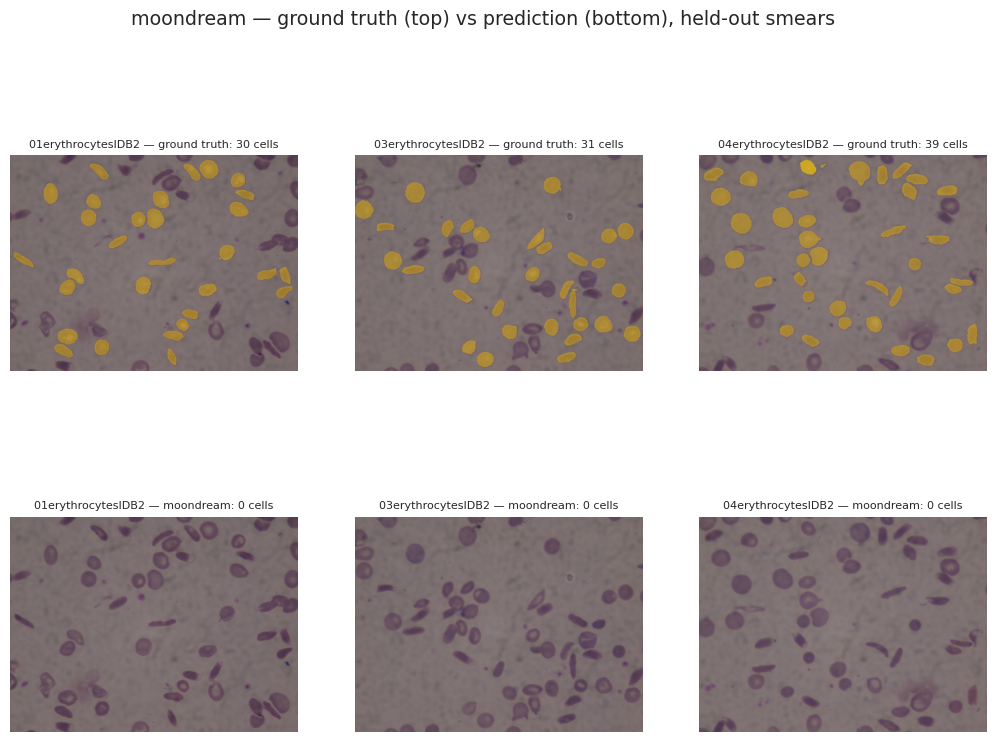

  moondream-boxlevel: 10/17 smears

  moondream-boxlevel   (17 held-out GT smears, 466 real cells)
  f1@50                0.1228
  precision@50         0.5818
  recall@50            0.0687
  mean_matched_iou     0.1228
  pixel_iou            0.0788
  mask_ap50            0.0551
  mask_ap50_95         0.0220
  sec_per_smear        0.3194
  NOTE: this method emits no confidence -> AP is order-arbitrary, read F1@50 instead.

ellipse vs solid box, F1@50: 0.123 vs 0.123 -- the gap is how much the ellipse prior costs, not the detector.


In [12]:
# ── the shared scorer, mask-level (ellipses) and box-level ──
def md_predict(rgb):
    b = md_boxes(rgb, MD_PROMPT)
    if MD_FILT:
        b = geom_filter(b, rgb.shape[:2], *MD_FILT)
    masks = boxes_to_masks(b, rgb.shape[:2], MD_GROW)
    return masks, [1.0] * len(masks)               # Moondream emits no confidence


def md_predict_box(rgb):
    '''same detections, but each box filled solid -> box-level IoU against GT box masks'''
    b = md_boxes(rgb, MD_PROMPT)
    if MD_FILT:
        b = geom_filter(b, rgb.shape[:2], *MD_FILT)
    H, W = rgb.shape[:2]
    out = []
    for x0, y0, x1, y1 in b:
        m = np.zeros((H, W), bool)
        m[max(int(y0), 0):int(y1) + 1, max(int(x0), 0):int(x1) + 1] = True
        if m.sum() >= 12:
            out.append(m)
    return out, [1.0] * len(out)


res_md, per_md = seg_benchmark(
    md_predict, 'moondream',
    notes=f'{CFG["md_model"]} @ {MD_REV}, prompt {MD_PROMPT!r}, boxes -> inscribed ellipses',
    extra={'model': CFG['md_model'], 'revision': MD_REV, 'prompt': MD_PROMPT,
           'ellipse_scale': MD_GROW, 'geometry_filter': list(MD_FILT) if MD_FILT else None,
           'adaptation': ADAPT, 'mask_source': 'inscribed ellipse per box'}, show=3)

res_mdb, _ = seg_benchmark(
    md_predict_box, 'moondream-boxlevel',
    notes='same detections, solid boxes -- isolates the ellipse approximation from the detector',
    extra={'model': CFG['md_model'], 'revision': MD_REV, 'prompt': MD_PROMPT,
           'adaptation': ADAPT, 'mask_source': 'solid box', 'exclude_from_shootout': True}, show=0)

print(f"\nellipse vs solid box, F1@50: {res_md['f1@50']:.3f} vs {res_mdb['f1@50']:.3f} "
      '-- the gap is how much the ellipse prior costs, not the detector.')
free_gpu('md_model')

In [13]:
# ═════════════════════════════════════════════════════════════════════════════
#  CHECKPOINT  ·  identical in every notebook of the series
#
#  Appends one record per run to  runs_two_stage/checkpoints.json  -- the single
#  file that answers "which stages have actually been run, on what hardware, how
#  long did they take, what did they write to disk, and what did they score?".
#  Re-running a stage APPENDS; nothing is overwritten, so the file is the run
#  history of the whole pipeline rather than a snapshot of the last run.
# ═════════════════════════════════════════════════════════════════════════════
CKPT_LOG = os.path.join(CFG['runs_dir'], 'checkpoints.json')


def _ckpt_art(p):
    '''one artefact -> exists / size / mtime. Directories are summarised, not listed.'''
    p = str(p)
    if not os.path.exists(p):
        return {'path': p, 'exists': False}
    if os.path.isdir(p):
        fs = [os.path.join(r, f) for r, _, ns in os.walk(p) for f in ns]
        mt = max([os.path.getmtime(f) for f in fs] or [os.path.getmtime(p)])
        return {'path': p, 'exists': True, 'kind': 'dir', 'files': len(fs),
                'mb': round(sum(os.path.getsize(f) for f in fs) / 2 ** 20, 2),
                'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(mt))}
    return {'path': p, 'exists': True, 'kind': 'file',
            'mb': round(os.path.getsize(p) / 2 ** 20, 3),
            'modified': time.strftime('%Y-%m-%d %H:%M', time.localtime(os.path.getmtime(p)))}


def _ckpt_val(v):
    '''keep the log json-safe: numbers stay numbers, NaN/inf become null, the rest becomes text'''
    if v is None or isinstance(v, (bool, str)):
        return v
    try:
        f = float(v)
    except (TypeError, ValueError):
        return str(v)
    return None if (math.isnan(f) or math.isinf(f)) else round(f, 6)


def _ckpt_minutes():
    '''wall-clock minutes this kernel has been alive = how long the run took, near enough'''
    try:
        import psutil
        return round((time.time() - psutil.Process(os.getpid()).create_time()) / 60, 2)
    except Exception:
        return None


def checkpoint(nb, produced=None, metrics=None, status='ok', notes=''):
    '''record that `nb` finished. `produced` = {label: path}; a falsy path is skipped,
    which is how the optional artefacts (a run dir that was not recreated, a table only
    one branch writes) stay out of the missing list.'''
    arts = {k: _ckpt_art(v) for k, v in (produced or {}).items() if v}
    missing = sorted(k for k, a in arts.items() if not a['exists'])
    rec = {'nb': nb,
           'status': 'MISSING ARTEFACTS' if missing else status,
           'finished': time.strftime('%Y-%m-%d %H:%M:%S'),
           'minutes': _ckpt_minutes(),
           'platform': PLATFORM, 'tier': TIER, 'gpu': GPU, 'vram_gb': round(VRAM, 1),
           'torch': torch.__version__, 'seed': SEED,
           'slurm_job': os.environ.get('SLURM_JOB_ID', ''),
           'runs_dir': CFG['runs_dir'],
           'metrics': {k: _ckpt_val(v) for k, v in (metrics or {}).items()},
           'artefacts': arts, 'missing': missing, 'notes': notes,
           'state_keys': sorted(read_state())}

    log = []
    if os.path.exists(CKPT_LOG):
        try:
            log = [r for r in json.load(open(CKPT_LOG)) if isinstance(r, dict)]
        except Exception:
            shutil.copy(CKPT_LOG, CKPT_LOG + '.corrupt')
            print(f'!! {CKPT_LOG} was unreadable -- copied to .corrupt, starting a new log')
    log.append(rec)
    tmp = f'{CKPT_LOG}.{os.getpid()}.tmp'          # atomic: two stages can finish at once
    json.dump(log, open(tmp, 'w'), indent=2, default=str)
    os.replace(tmp, CKPT_LOG)

    print('\n' + '=' * 78)
    print(f'  CHECKPOINT  {nb}   [{rec["status"]}]'
          + (f'   {rec["minutes"]:.1f} min' if rec['minutes'] else ''))
    print(f'  -> {CKPT_LOG}   ({len(log)} records)')
    print('=' * 78)
    for k, a in arts.items():
        print(f'  {"ok  " if a["exists"] else "MISS"}  {k:<20s} {a.get("mb", 0):>9.2f} MB  '
              f'{a["path"]}')
    for k, v in rec['metrics'].items():
        print(f'  metric  {k:<20s} {v}')
    last = {r['nb']: r for r in log}              # one row per stage, most recent run wins
    print(f'\n  stages recorded in this runs_dir ({len(last)}):')
    for k in sorted(last):
        r = last[k]
        print(f'   {"ok" if r["status"] == "ok" else "!!"}  {k:<40s} {r["finished"]}  '
              f'tier {r.get("tier", "?")}')
    return rec

checkpoint(
    '03_segmentation_moondream',
    produced={'result': os.path.join(BENCH, 'moondream.json'),
              'boxlevel_result': os.path.join(BENCH, 'moondream-boxlevel.json'),
              'prompt_sweep': os.path.join(TAB, 'moondream_prompt_sweep.csv'),
              'geometry_sweep': os.path.join(TAB, 'moondream_geometry_sweep.csv')},
    metrics={'f1@50': res_md['f1@50'], 'boxlevel_f1@50': res_mdb['f1@50'],
             'precision@50': res_md['precision@50'],
             'recall@50': res_md['recall@50'],
             'sec_per_smear': res_md['sec_per_smear'],
             'prompt': MD_PROMPT, 'revision': MD_REV},
    notes=f'{ADAPT} -- masks are ellipses fitted to boxes, and it emits no confidence')


  CHECKPOINT  03_segmentation_moondream   [ok]   5.1 min
  -> /home/bahajao/runs_two_stage/checkpoints.json   (4 records)
  ok    result                    0.00 MB  /home/bahajao/runs_two_stage/seg_bench/moondream.json
  ok    boxlevel_result           0.00 MB  /home/bahajao/runs_two_stage/seg_bench/moondream-boxlevel.json
  ok    prompt_sweep              0.00 MB  /home/bahajao/runs_two_stage/tables/moondream_prompt_sweep.csv
  ok    geometry_sweep            0.00 MB  /home/bahajao/runs_two_stage/tables/moondream_geometry_sweep.csv
  metric  f1@50                0.122841
  metric  boxlevel_f1@50       0.122841
  metric  precision@50         0.581818
  metric  recall@50            0.06867
  metric  sec_per_smear        0.320229
  metric  prompt               erythrocyte
  metric  revision             2025-06-21

  stages recorded in this runs_dir (4):
   ok  00_setup_and_data                        2026-08-03 09:55:00  tier a100
   ok  01_segmentation_yolo                     2026-08-

{'nb': '03_segmentation_moondream',
 'status': 'ok',
 'finished': '2026-08-03 10:28:35',
 'minutes': 5.08,
 'platform': 'ibex',
 'tier': 'a100',
 'gpu': 'NVIDIA A100-SXM4-80GB',
 'vram_gb': 79.3,
 'torch': '2.1.2',
 'seed': 42,
 'slurm_job': '49919771',
 'runs_dir': '/home/bahajao/runs_two_stage',
 'metrics': {'f1@50': 0.122841,
  'boxlevel_f1@50': 0.122841,
  'precision@50': 0.581818,
  'recall@50': 0.06867,
  'sec_per_smear': 0.320229,
  'prompt': 'erythrocyte',
  'revision': '2025-06-21'},
 'artefacts': {'result': {'path': '/home/bahajao/runs_two_stage/seg_bench/moondream.json',
   'exists': True,
   'kind': 'file',
   'mb': 0.001,
   'modified': '2026-08-03 10:28'},
  'boxlevel_result': {'path': '/home/bahajao/runs_two_stage/seg_bench/moondream-boxlevel.json',
   'exists': True,
   'kind': 'file',
   'mb': 0.001,
   'modified': '2026-08-03 10:28'},
  'prompt_sweep': {'path': '/home/bahajao/runs_two_stage/tables/moondream_prompt_sweep.csv',
   'exists': True,
   'kind': 'file',
   '